In [3]:
import pandas as pd

df = pd.read_csv("Data/final_dataset.csv")

print(df.shape)
df.head()

(63249, 23)


,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,opening_weekend_gross,gross_worldwide,gross_us_canada,release_date,countries_origin,filming_locations,production_companies,awards_content,genres,languages
0,tt0080125,West Indies,1h 50m,NaN,7.1,301,NaN,This vast musical fresco covers hundreds of ye...,https://www.imdb.com/title/tt0080125/,"['Daniel Boukman', 'Med Hondo']",...,NaN,NaN,NaN,3/18/1985,"['France', 'Algeria', 'Mauritania']",NaN,"['Les Films Soleil O', 'Office National de Cin...",NaN,"['Drama', 'Musical']",['French']
1,tt0249500,Estafa de amor,1h 33m,NaN,6.7,14,NaN,NaN,https://www.imdb.com/title/tt0249500/,"['Caridad Bravo Adams', 'Miguel M. Delgado', '...",...,NaN,NaN,NaN,9/27/1956,['Mexico'],NaN,['Filmadora Chapultepec'],NaN,['Drama'],['Spanish']
2,tt0054151,Brother,1h 38m,NaN,6.9,498,NaN,Set in 1926 when Japanese tradition was much s...,https://www.imdb.com/title/tt0054151/,"['Aya Kôda', 'Yôko Mizuki']",...,NaN,NaN,NaN,11/1/1960,['Japan'],NaN,['Daiei'],NaN,['Drama'],['Japanese']
3,tt6136430,Ferrante Fever,1h 14m,NaN,6.3,196,52.0,"Hillary Clinton, Roberto Saviano, Jonathan Fra...",https://www.imdb.com/title/tt6136430/,"['Laura Buffoni', 'Giacomo Durzi']",...,"$3,509","$14,518","$11,137",3/8/2019,"['Italy', 'France']","['Manhattan, New York City, New York, USA']","['Malìa', 'Rai Cinema', 'QMI']",NaN,['Documentary'],"['Italian', 'French', 'English']"
4,tt30395619,Demon Slayer: Kimetsu No Yaiba - To the Hashir...,1h 44m,R,7.1,8.3K,61.0,Tanjiro undergoes rigorous training with the S...,https://www.imdb.com/title/tt30395619/,['Koyoharu Gotouge'],...,"$11,505,414","$44,354,825","$17,657,658",2/23/2024,['Japan'],NaN,"['Shueisha', 'Aniplex', 'Ufotable']",NaN,"['Anime', 'Dark Fantasy', 'Shōnen', 'Supernatu...",['Japanese']


In [4]:
print(df.columns.tolist())

['id', 'title', 'duration', 'mpa', 'rating', 'votes', 'méta_score', 'description', 'movie_link', 'writers', 'directors', 'stars', 'budget', 'opening_weekend_gross', 'gross_worldwide', 'gross_us_canada', 'release_date', 'countries_origin', 'filming_locations', 'production_companies', 'awards_content', 'genres', 'languages']


In [5]:
import numpy as np
import re
import ast

def parse_duration(duration_str):
    if pd.isna(duration_str):
        return np.nan
    
    duration_str = str(duration_str)
    
    hours = 0
    minutes = 0
    
    h = re.search(r'(\d+)h', duration_str)
    m = re.search(r'(\d+)m', duration_str)
    
    if h:
        hours = int(h.group(1))
    if m:
        minutes = int(m.group(1))
    
    return hours * 60 + minutes

def parse_votes(vote_str):
    if pd.isna(vote_str):
        return np.nan
    
    vote_str = str(vote_str).replace(",", "")
    
    if "K" in vote_str:
        return float(vote_str.replace("K", "")) * 1000
    if "M" in vote_str:
        return float(vote_str.replace("M", "")) * 1000000
    
    try:
        return float(vote_str)
    except:
        return np.nan

def parse_list(x):
    try:
        return ast.literal_eval(x)
    except:
        return []

df["duration_min"] = df["duration"].apply(parse_duration)
df["votes_num"] = df["votes"].apply(parse_votes)
df["genres_list"] = df["genres"].apply(parse_list)
df["countries_list"] = df["countries_origin"].apply(parse_list)

df[["duration", "duration_min", "votes", "votes_num"]].head()

,duration,duration_min,votes,votes_num
0,1h 50m,110.0,301,301.0
1,1h 33m,93.0,14,14.0
2,1h 38m,98.0,498,498.0
3,1h 14m,74.0,196,196.0
4,1h 44m,104.0,8.3K,8300.0


In [6]:
country_df = df.copy()

# split multiple countries into separate rows
country_df = country_df.explode("countries_list")

# rename for clarity
country_df = country_df.rename(columns={"countries_list": "country"})

# clean country column
country_df["country"] = country_df["country"].astype(str).str.strip()

# remove empty values
country_df = country_df[(country_df["country"] != "") & (country_df["country"] != "[]")]

# group and calculate average rating
country_summary = (
    country_df.groupby("country")
    .agg(
        n_movies=("id", "count"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)

# keep only countries with enough data
country_summary = country_summary[country_summary["n_movies"] >= 50]

# sort by rating
country_summary = country_summary.sort_values("avg_rating", ascending=False)

country_summary.head(15)

,country,n_movies,avg_rating
72,Iran,105,7.133981
41,Czechoslovakia,257,6.908032
146,Soviet Union,678,6.885714
141,Singapore,53,6.820755
47,Egypt,132,6.767460
69,Iceland,65,6.706154
68,Hungary,323,6.685942
175,Yugoslavia,273,6.661538
70,India,2762,6.660954
131,Romania,153,6.659603


## Research Question 1  
How do movie ratings vary across countries of origin?

### Interpretation  
This plot shows the top 15 countries with the highest average movie ratings.  
We observe that countries such as Iran and Czechoslovakia rank highly.  

This may suggest that smaller film industries produce fewer but more critically acclaimed films.  
However, this could also reflect selection bias, where only the highest-quality films gain international visibility.

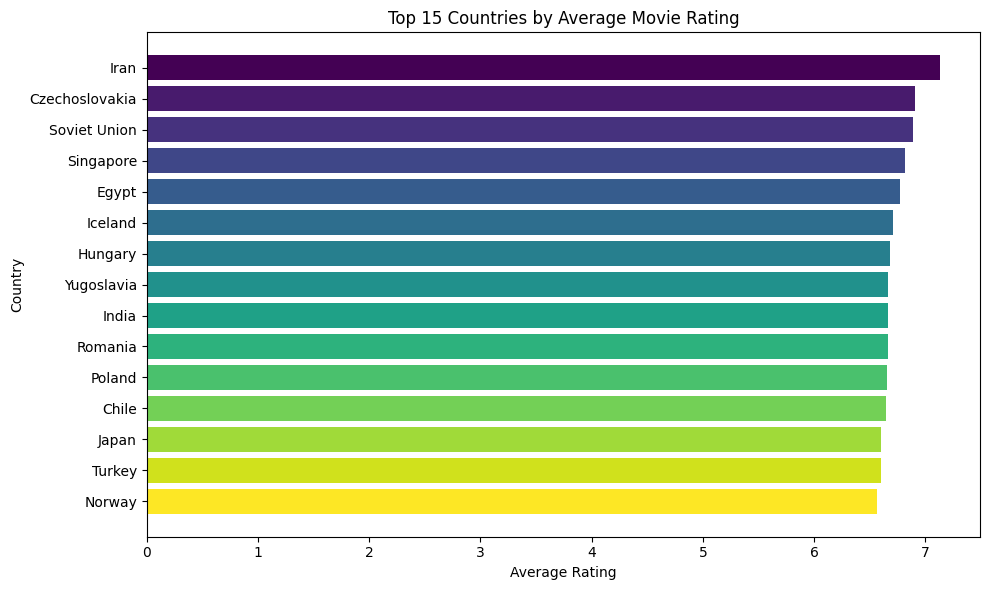

In [8]:
import matplotlib.pyplot as plt
import numpy as np

top_countries = country_summary.head(15)

# create gradient colors
colors = plt.cm.viridis(np.linspace(0, 1, len(top_countries)))

plt.figure(figsize=(10, 6))
plt.barh(top_countries["country"], top_countries["avg_rating"], color=colors)

plt.xlabel("Average Rating")
plt.ylabel("Country")
plt.title("Top 15 Countries by Average Movie Rating")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Research Question 2  
Which genres receive the highest ratings and most audience engagement (votes)?

In [9]:
genre_df = df.copy()

# split genres into separate rows
genre_df = genre_df.explode("genres_list")

# rename
genre_df = genre_df.rename(columns={"genres_list": "genre"})

# clean
genre_df["genre"] = genre_df["genre"].astype(str).str.strip()
genre_df = genre_df[(genre_df["genre"] != "") & (genre_df["genre"] != "[]")]

# group
genre_summary = (
    genre_df.groupby("genre")
    .agg(
        n_movies=("id", "count"),
        avg_rating=("rating", "mean"),
        avg_votes=("votes_num", "mean")
    )
    .reset_index()
)

# filter for reliability
genre_summary = genre_summary[genre_summary["n_movies"] >= 50]

# sort by rating
genre_summary = genre_summary.sort_values("avg_rating", ascending=False)

genre_summary.head(15)

,genre,n_movies,avg_rating,avg_votes
151,Sports Documentary,51,7.543137,9631.980392
49,Epic,270,7.455762,318391.687732
182,War Epic,118,7.227350,137741.461538
74,Historical Epic,89,7.176404,81803.235955
102,Music Documentary,53,7.160377,8815.245283
175,Tragedy,629,7.129777,130651.699045
106,News,71,7.118841,2145.884058
128,Samurai,61,7.085246,46406.459016
45,Documentary,2999,7.075661,2889.250508
44,Docudrama,388,7.054026,121981.462338


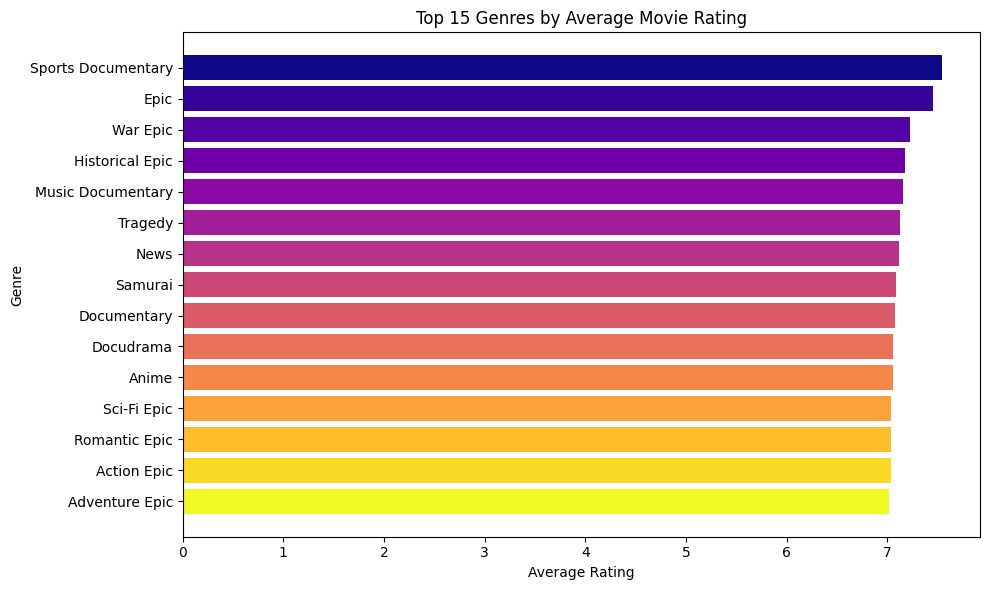

In [10]:
import numpy as np
import matplotlib.pyplot as plt

top_genres = genre_summary.head(15)

colors = plt.cm.plasma(np.linspace(0, 1, len(top_genres)))

plt.figure(figsize=(10, 6))
plt.barh(top_genres["genre"], top_genres["avg_rating"], color=colors)

plt.xlabel("Average Rating")
plt.ylabel("Genre")
plt.title("Top 15 Genres by Average Movie Rating")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation  

This plot shows the top 15 genres with the highest average movie ratings.  
We observe that certain genres consistently receive higher ratings, indicating stronger audience appreciation.  

Genres with more niche or artistic appeal may rank higher in ratings, while more mainstream genres may attract broader audiences but not always the highest scores.  

This highlights a distinction between popularity (votes) and perceived quality (ratings).

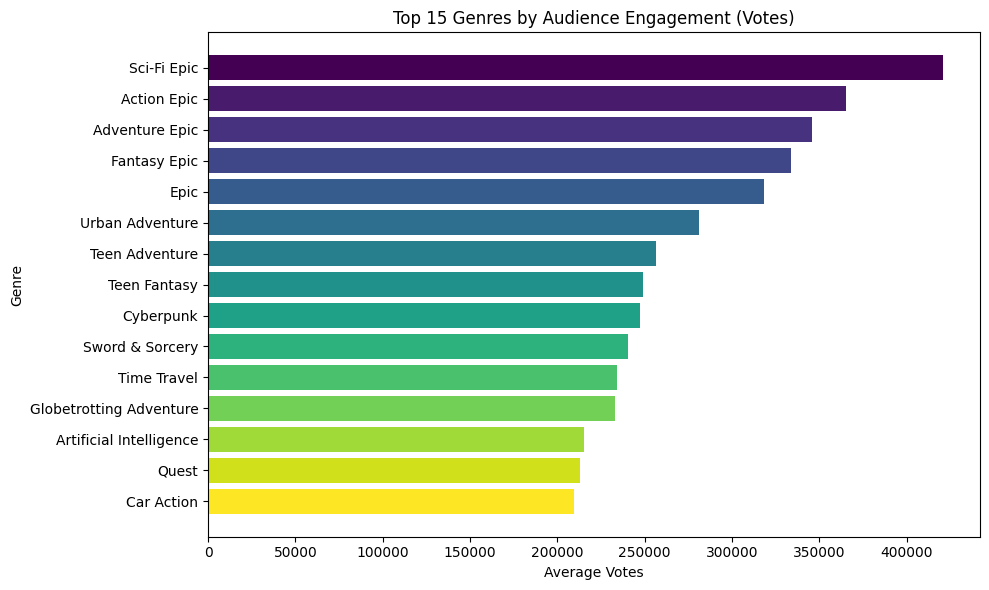

In [11]:
top_votes = genre_summary.sort_values("avg_votes", ascending=False).head(15)

colors = plt.cm.viridis(np.linspace(0, 1, len(top_votes)))

plt.figure(figsize=(10, 6))
plt.barh(top_votes["genre"], top_votes["avg_votes"], color=colors)

plt.xlabel("Average Votes")
plt.ylabel("Genre")
plt.title("Top 15 Genres by Audience Engagement (Votes)")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Interpretation (Votes)  

This plot highlights genres that receive the highest audience engagement.  

We may observe that more mainstream or widely distributed genres attract significantly more votes, even if they do not always have the highest ratings.  

This suggests a difference between popularity and critical evaluation.

## Research Question 3  
How does movie duration influence audience ratings and votes?

In [13]:
duration_df = df.copy()

duration_df = duration_df.dropna(subset=["duration_min", "rating", "votes_num"])

duration_df.head()

,id,title,duration,mpa,rating,votes,méta_score,description,movie_link,writers,...,countries_origin,filming_locations,production_companies,awards_content,genres,languages,duration_min,votes_num,genres_list,countries_list
0,tt0080125,West Indies,1h 50m,NaN,7.1,301,NaN,This vast musical fresco covers hundreds of ye...,https://www.imdb.com/title/tt0080125/,"['Daniel Boukman', 'Med Hondo']",...,"['France', 'Algeria', 'Mauritania']",NaN,"['Les Films Soleil O', 'Office National de Cin...",NaN,"['Drama', 'Musical']",['French'],110.0,301.0,"[Drama, Musical]","[France, Algeria, Mauritania]"
1,tt0249500,Estafa de amor,1h 33m,NaN,6.7,14,NaN,NaN,https://www.imdb.com/title/tt0249500/,"['Caridad Bravo Adams', 'Miguel M. Delgado', '...",...,['Mexico'],NaN,['Filmadora Chapultepec'],NaN,['Drama'],['Spanish'],93.0,14.0,[Drama],[Mexico]
2,tt0054151,Brother,1h 38m,NaN,6.9,498,NaN,Set in 1926 when Japanese tradition was much s...,https://www.imdb.com/title/tt0054151/,"['Aya Kôda', 'Yôko Mizuki']",...,['Japan'],NaN,['Daiei'],NaN,['Drama'],['Japanese'],98.0,498.0,[Drama],[Japan]
3,tt6136430,Ferrante Fever,1h 14m,NaN,6.3,196,52.0,"Hillary Clinton, Roberto Saviano, Jonathan Fra...",https://www.imdb.com/title/tt6136430/,"['Laura Buffoni', 'Giacomo Durzi']",...,"['Italy', 'France']","['Manhattan, New York City, New York, USA']","['Malìa', 'Rai Cinema', 'QMI']",NaN,['Documentary'],"['Italian', 'French', 'English']",74.0,196.0,[Documentary],"[Italy, France]"
4,tt30395619,Demon Slayer: Kimetsu No Yaiba - To the Hashir...,1h 44m,R,7.1,8.3K,61.0,Tanjiro undergoes rigorous training with the S...,https://www.imdb.com/title/tt30395619/,['Koyoharu Gotouge'],...,['Japan'],NaN,"['Shueisha', 'Aniplex', 'Ufotable']",NaN,"['Anime', 'Dark Fantasy', 'Shōnen', 'Supernatu...",['Japanese'],104.0,8300.0,"[Anime, Dark Fantasy, Shōnen, Supernatural Fan...",[Japan]


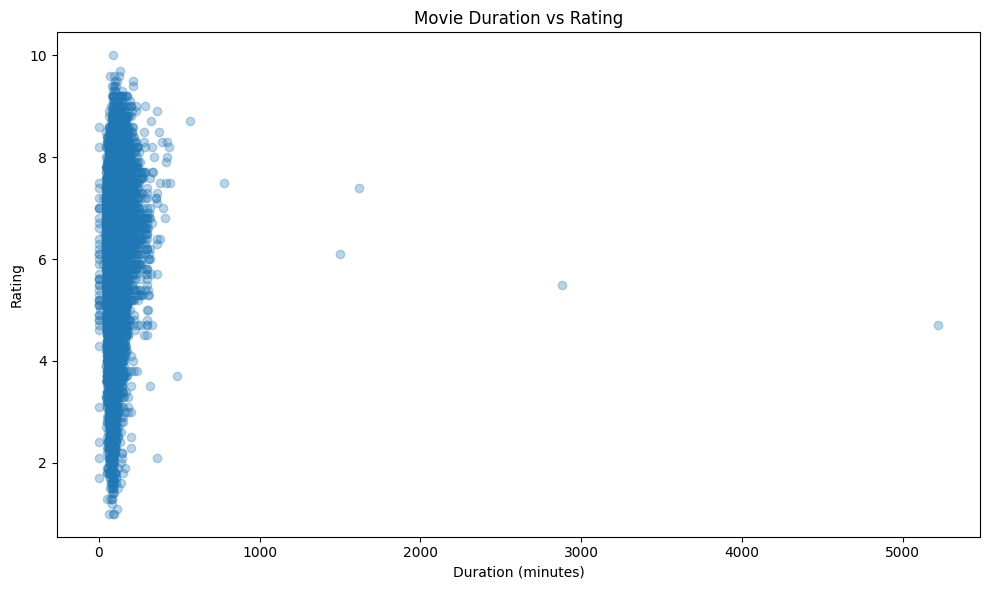

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(duration_df["duration_min"], duration_df["rating"], alpha=0.3)

plt.xlabel("Duration (minutes)")
plt.ylabel("Rating")
plt.title("Movie Duration vs Rating")

plt.tight_layout()
plt.show()

### Interpretation  

This plot explores the relationship between movie duration and audience ratings.  

We observe that most movies fall within a typical duration range of approximately 80 to 150 minutes. Within this range, ratings are widely distributed, indicating that duration alone does not determine how highly a movie is rated.  

There is no clear linear relationship between duration and ratings, suggesting that longer movies are not necessarily better or worse in terms of audience evaluation.  

This implies that other factors such as genre, storytelling quality, and production value likely play a more significant role in determining a movie’s success.

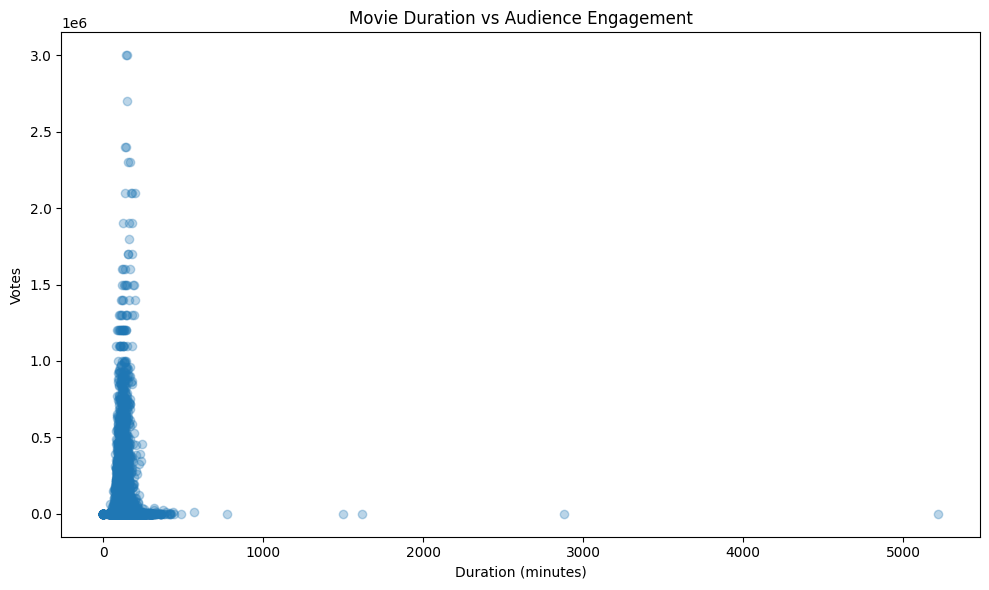

In [15]:
plt.figure(figsize=(10, 6))
plt.scatter(duration_df["duration_min"], duration_df["votes_num"], alpha=0.3)

plt.xlabel("Duration (minutes)")
plt.ylabel("Votes")
plt.title("Movie Duration vs Audience Engagement")

plt.tight_layout()
plt.show()

### Interpretation (Votes)  

This plot examines how movie duration relates to audience engagement, measured by the number of votes.  

We observe that movies of varying durations can achieve high engagement, although extremely short or very long movies appear less frequently.  

There is no strong pattern indicating that longer movies consistently receive more votes. This suggests that audience engagement is influenced more by popularity, accessibility, and genre rather than duration alone.